In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

matplotlib 3.11.0
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.1+cu130
cuda:0


In [2]:
from torchvision import datasets, transforms
import os
import shutil

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224))
])

# 设置数据集路径
data_dir = os.path.join('data' , 'monkey_10')

for root, dirs, files in os.walk(data_dir):
    if ".ipynb_checkpoints" in dirs:
        checkpoint_path = os.path.join(root, ".ipynb_checkpoints")
        shutil.rmtree(checkpoint_path)
        print(f"已删除: {checkpoint_path}")

train_dir = os.path.join(data_dir, 'training')
validation_dir = os.path.join(data_dir, 'validation')

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
validation_dataset = datasets.ImageFolder(validation_dir, transform=transform)

print(f"训练集样本数: {len(train_dataset)}")
print(f"测试集样本数: {len(validation_dataset)}")

训练集样本数: 1097
测试集样本数: 272


In [3]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

batch_size = 64

loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
channels_sum = torch.zeros(3)
channels_squared_sum = torch.zeros(3)
num_pixels = 0

for images, _ in tqdm(loader , desc="计算均值和标准差"):
    # images.shape = (B, C, H, W)  B: batch_size, C: 通道数, H: 高, W: 宽
    channels_sum += images.sum(dim=[0,2,3])
    channels_squared_sum += (images**2).sum(dim=[0,2,3])
    num_pixels += images.numel() / 3

mean =  channels_sum / num_pixels
std = (channels_squared_sum / num_pixels - mean ** 2) ** 0.5

print(f"训练集均值: {mean}")
print(f"训练集标准差: {std}")

计算均值和标准差: 100%|██████████| 18/18 [00:11<00:00,  1.57it/s]

训练集均值: tensor([0.4363, 0.4328, 0.3291])
训练集标准差: tensor([0.2464, 0.2419, 0.2453])


In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 设置数据集路径
data_dir = os.path.join('data' , 'monkey_10')

train_dir = os.path.join(data_dir, 'training')
validation_dir = os.path.join(data_dir, 'validation')

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
validation_dataset = datasets.ImageFolder(validation_dir, transform=val_transform)

In [5]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
num_classes = len(train_dataset.classes)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")
print(f"训练集的样本数：{num_classes}")

训练集DataLoader批次数: 18
测试集DataLoader批次数: 5
每个批次大小: 64
训练集的样本数：10


In [6]:
# 模型搭建

class CNN_monkey(nn.Module):

    INPUT_CHANNELS = 3
    NUM_CLASSES = 10
    CONV_CHANNELS_BLOCK1 = 32
    CONV_CHANNELS_BLOCK2 = 64
    CONV_CHANNELS_BLOCK3 = 128
    CONV_CHANNELS_BLOCK4 = 256
    CONV_CHANNELS_BLOCK5 = 512
    FC_HIDDEN_SIZE = 128
    DROPOUT_RATE = 0.2

    def __init__(self , num_classes):
        super().__init__()
        self.conv1_block = nn.Sequential(
            nn.Conv2d(
                in_channels=self.INPUT_CHANNELS, 
                out_channels=self.CONV_CHANNELS_BLOCK1, 
                kernel_size=3, 
                stride=1, 
                padding='same'
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK1),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=self.CONV_CHANNELS_BLOCK1,
                out_channels=self.CONV_CHANNELS_BLOCK1,
                kernel_size=3,
                stride=1,
                padding='same'
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ) # 输出 32 * 128 * 128

        self.conv2_block = nn.Sequential(
            nn.Conv2d(
                in_channels=self.CONV_CHANNELS_BLOCK1,
                out_channels=self.CONV_CHANNELS_BLOCK2,
                kernel_size=3,
                stride=1,
                padding='same'
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK2),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=self.CONV_CHANNELS_BLOCK2,
                out_channels=self.CONV_CHANNELS_BLOCK2,
                kernel_size=3,
                stride=1,
                padding='same'
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ) # 输出 64 * 64 * 64

        self.conv3_block = nn.Sequential(
            nn.Conv2d(
                in_channels=self.CONV_CHANNELS_BLOCK2,
                out_channels=self.CONV_CHANNELS_BLOCK3,
                kernel_size=3,
                stride=1,
                padding='same'
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK3),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=self.CONV_CHANNELS_BLOCK3,
                out_channels=self.CONV_CHANNELS_BLOCK3,
                kernel_size=3,
                stride=1,
                padding='same'
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ) # 输出 128 * 32 * 32

        self.conv4_block = nn.Sequential(
            nn.Conv2d(
                in_channels=self.CONV_CHANNELS_BLOCK3,
                out_channels=self.CONV_CHANNELS_BLOCK4,
                kernel_size=3,
                stride=1,
                padding='same'
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK4),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=self.CONV_CHANNELS_BLOCK4,
                out_channels=self.CONV_CHANNELS_BLOCK4,
                kernel_size=3,
                stride=1,
                padding='same'
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ) # 输出 256 * 16 * 16

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=self.CONV_CHANNELS_BLOCK4,
                out_features=self.FC_HIDDEN_SIZE
            ),
            nn.ReLU(),
            nn.Dropout(self.DROPOUT_RATE),
            nn.Linear(
                in_features=self.FC_HIDDEN_SIZE,
                out_features=self.NUM_CLASSES
            )
        )

    def forward(self, x):
        x = self.conv1_block(x)
        x = self.conv2_block(x)
        x = self.conv3_block(x)
        x = self.conv4_block(x)
        x = self.avgpool(x)
        x = self.fc_layer(x)
        return x

model = CNN_monkey(num_classes).to(device)
print(model)

CNN_monkey(
  (conv1_block): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2_block): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )

In [7]:
dummy_input = torch.randn(128, 3, 258, 256).to(device)
output = model(dummy_input)
print(output.shape)

torch.Size([128, 10])


In [8]:
total_params = sum(p.numel() for p in model.parameters())
total_params

1208362

In [9]:
import torch.optim as optim
import model_trainer as mt

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

trainer = mt.Trainer(
    model = model,
    train_loader = train_loader,
    val_loader = test_loader,
    criterion = criterion,
    optimizer = optimizer,
    device = device,
    eval_step=len(train_loader)
)

trainer.train(num_epochs=20);

[Step 18] Val Loss: 2.2951 Val Acc: 0.2059
Epoch [1/20] Train Loss: 2.0580 Train Acc: 0.2653
[Step 36] Val Loss: 1.6716 Val Acc: 0.3640
Epoch [2/20] Train Loss: 1.8529 Train Acc: 0.3072
[Step 54] Val Loss: 1.8120 Val Acc: 0.3419
Epoch [3/20] Train Loss: 1.8051 Train Acc: 0.3573
[Step 72] Val Loss: 1.6362 Val Acc: 0.3934
Epoch [4/20] Train Loss: 1.7158 Train Acc: 0.3710
[Step 90] Val Loss: 1.5632 Val Acc: 0.4191
Epoch [5/20] Train Loss: 1.6724 Train Acc: 0.3892
[Step 108] Val Loss: 1.8718 Val Acc: 0.4007
Epoch [6/20] Train Loss: 1.7177 Train Acc: 0.3756
[Step 126] Val Loss: 1.4661 Val Acc: 0.5037
Epoch [7/20] Train Loss: 1.6307 Train Acc: 0.4084
[Step 144] Val Loss: 1.4930 Val Acc: 0.4669
Epoch [8/20] Train Loss: 1.6415 Train Acc: 0.4102
[Step 162] Val Loss: 1.4768 Val Acc: 0.4449
Epoch [9/20] Train Loss: 1.6315 Train Acc: 0.4248
[Step 180] Val Loss: 1.4714 Val Acc: 0.4449
Epoch [10/20] Train Loss: 1.5769 Train Acc: 0.4512
[Step 198] Val Loss: 1.4085 Val Acc: 0.5368
Epoch [11/20] Train 

训练集记录点数: 360
验证集记录点数: 20


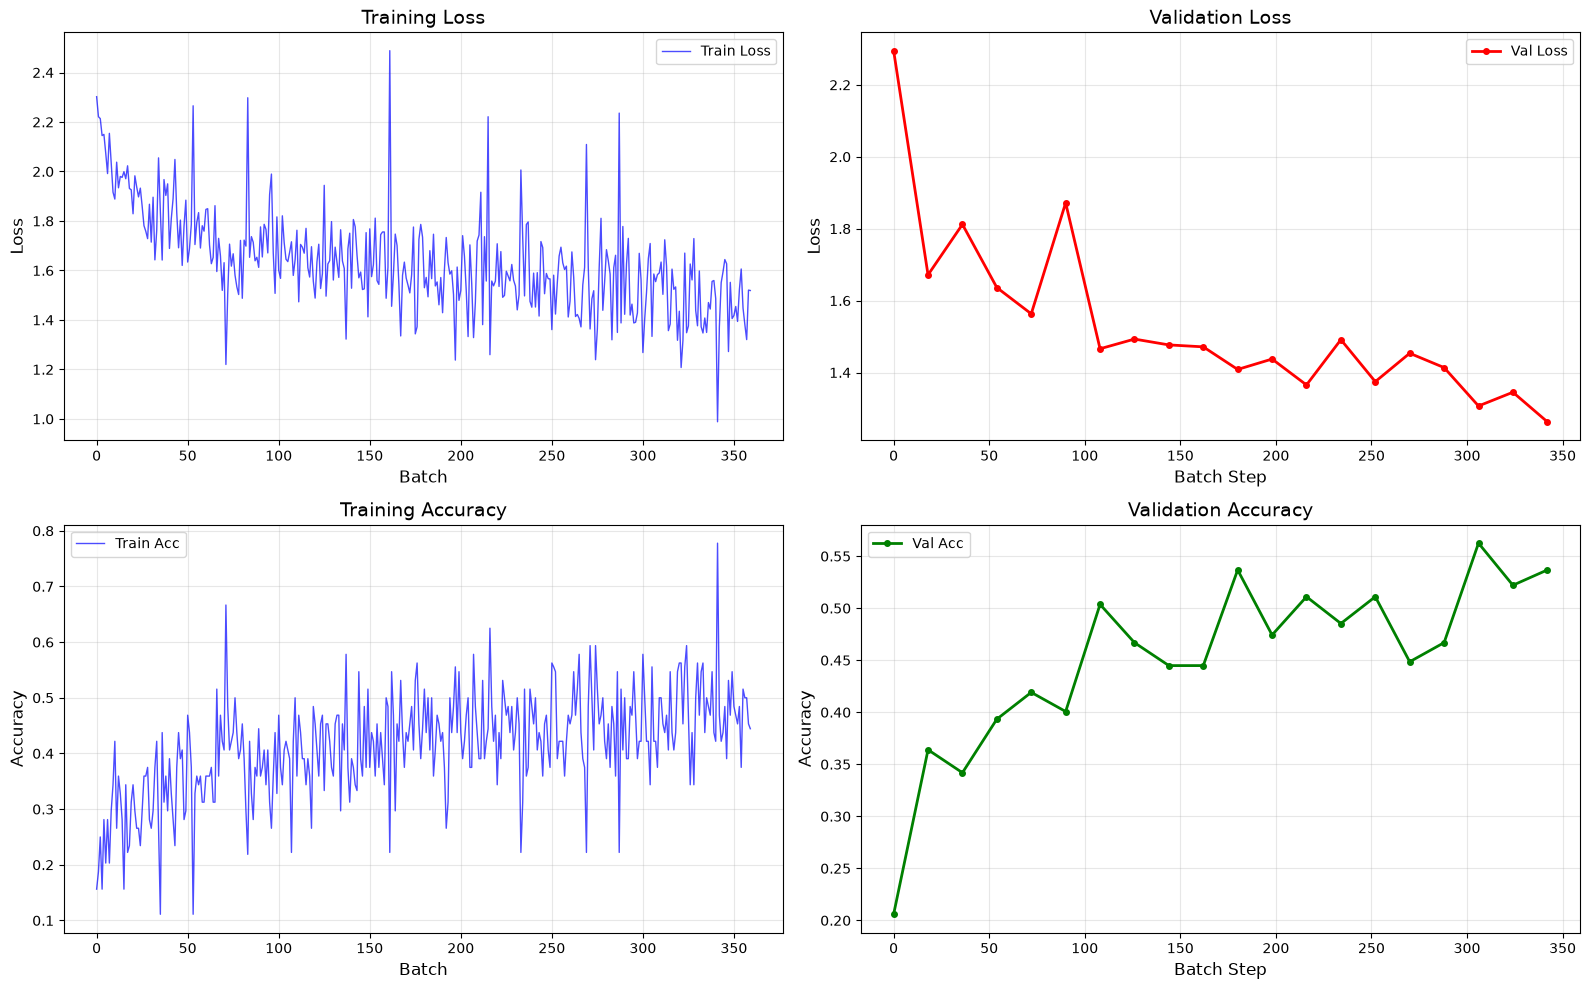


最终训练损失: 1.5189
最终训练准确率: 0.4444
最终验证损失: 1.2630
最终验证准确率: 0.5368

最佳验证损失: 1.2630 (Step 342)
最佳验证准确率: 0.5625 (Step 306)


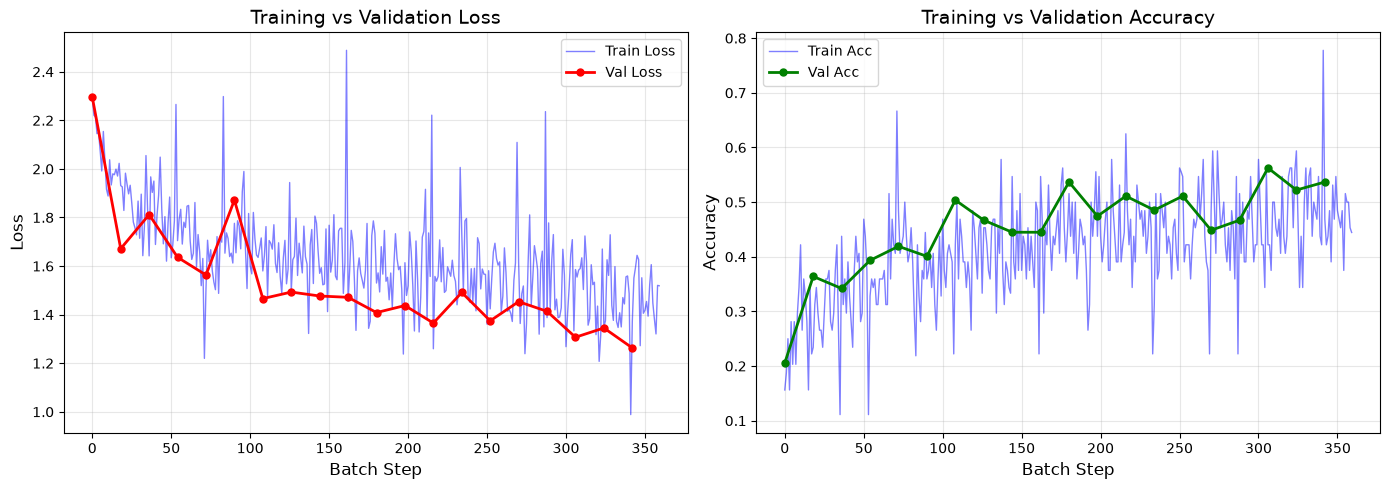

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 获取训练和验证的历史记录
train_loss_history = trainer.history.train_loss_history
train_acc_history = trainer.history.train_acc_history
val_loss_history = trainer.history.val_loss_history
val_acc_history = trainer.history.val_acc_history

print(f"训练集记录点数: {len(train_loss_history)}")
print(f"验证集记录点数: {len(val_loss_history)}")

if len(train_loss_history) > 0 and len(val_loss_history) > 0:
    # 创建2x2子图
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 训练损失曲线
    axes[0, 0].plot(train_loss_history, 'b-', linewidth=1, alpha=0.7, label='Train Loss')
    axes[0, 0].set_xlabel('Batch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Training Loss', fontsize=14)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 验证损失曲线
    val_steps = np.arange(0, len(val_loss_history)) * trainer.eval_step
    axes[0, 1].plot(val_steps, val_loss_history, 'r-', linewidth=2, marker='o', markersize=4, label='Val Loss')
    axes[0, 1].set_xlabel('Batch Step', fontsize=12)
    axes[0, 1].set_ylabel('Loss', fontsize=12)
    axes[0, 1].set_title('Validation Loss', fontsize=14)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 训练准确率曲线
    axes[1, 0].plot(train_acc_history, 'b-', linewidth=1, alpha=0.7, label='Train Acc')
    axes[1, 0].set_xlabel('Batch', fontsize=12)
    axes[1, 0].set_ylabel('Accuracy', fontsize=12)
    axes[1, 0].set_title('Training Accuracy', fontsize=14)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 验证准确率曲线
    axes[1, 1].plot(val_steps, val_acc_history, 'g-', linewidth=2, marker='o', markersize=4, label='Val Acc')
    axes[1, 1].set_xlabel('Batch Step', fontsize=12)
    axes[1, 1].set_ylabel('Accuracy', fontsize=12)
    axes[1, 1].set_title('Validation Accuracy', fontsize=14)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 打印最终统计信息
    print(f"\n{'='*60}")
    print(f"最终训练损失: {train_loss_history[-1]:.4f}")
    print(f"最终训练准确率: {train_acc_history[-1]:.4f}")
    print(f"最终验证损失: {val_loss_history[-1]:.4f}")
    print(f"最终验证准确率: {val_acc_history[-1]:.4f}")
    print(f"{'='*60}")
    
    if len(val_loss_history) > 1:
        best_val_loss_idx = np.argmin(val_loss_history)
        best_val_acc_idx = np.argmax(val_acc_history)
        print(f"\n最佳验证损失: {val_loss_history[best_val_loss_idx]:.4f} (Step {val_steps[best_val_loss_idx]})")
        print(f"最佳验证准确率: {val_acc_history[best_val_acc_idx]:.4f} (Step {val_steps[best_val_acc_idx]})")
        
        # 绘制train和val的对比图
        fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
        
        # Loss对比
        axes2[0].plot(train_loss_history, 'b-', linewidth=1, alpha=0.5, label='Train Loss')
        axes2[0].plot(val_steps, val_loss_history, 'r-', linewidth=2, marker='o', markersize=5, label='Val Loss')
        axes2[0].set_xlabel('Batch Step', fontsize=12)
        axes2[0].set_ylabel('Loss', fontsize=12)
        axes2[0].set_title('Training vs Validation Loss', fontsize=14)
        axes2[0].legend()
        axes2[0].grid(True, alpha=0.3)
        
        # Accuracy对比
        axes2[1].plot(train_acc_history, 'b-', linewidth=1, alpha=0.5, label='Train Acc')
        axes2[1].plot(val_steps, val_acc_history, 'g-', linewidth=2, marker='o', markersize=5, label='Val Acc')
        axes2[1].set_xlabel('Batch Step', fontsize=12)
        axes2[1].set_ylabel('Accuracy', fontsize=12)
        axes2[1].set_title('Training vs Validation Accuracy', fontsize=14)
        axes2[1].legend()
        axes2[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('training_curves_combined.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print("没有收集到训练或验证数据！")

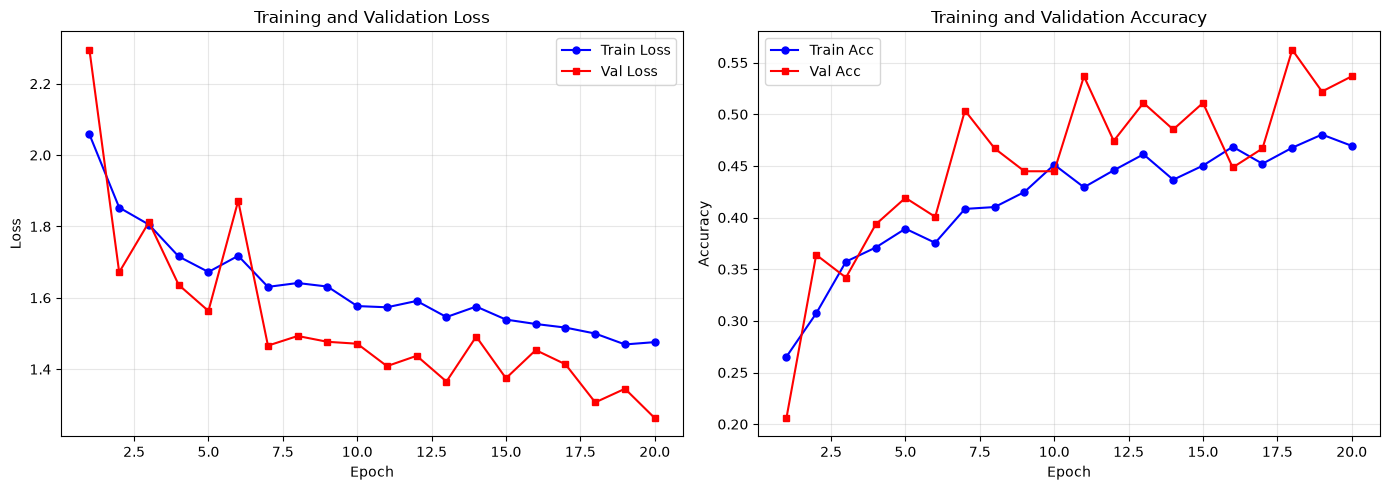

In [11]:
trainer.plot_curves()

In [12]:
from torchvision.models import resnet50

class Resnet50Model(nn.Module):
    def __init__(self , num_classes , frozen):
        super().__init__()
        self.model = resnet50(weights = 'IMAGENET1K_V2')
        if frozen:
            for param in self.model.parameters():
                param.requires_grad = False
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features , num_classes)
    
    def forward(self , x):
        return self.model(x)

resnet50_model = Resnet50Model(num_classes = 10 , frozen = True).to(device)
print(resnet50_model)

Resnet50Model(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=Tr

In [13]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 设置数据集路径
data_dir = os.path.join('data' , 'monkey_10')

train_dir = os.path.join(data_dir, 'training')
validation_dir = os.path.join(data_dir, 'validation')

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
validation_dataset = datasets.ImageFolder(validation_dir, transform=val_transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
num_classes = len(train_dataset.classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50_model.parameters(), lr=0.001)

Resnet50Trainer = mt.Trainer(
    model = resnet50_model,
    train_loader = train_loader,
    val_loader = test_loader,
    criterion = criterion,
    optimizer = optimizer,
    device = device,
    eval_step=len(train_loader)
)

Resnet50Trainer.train(num_epochs = 20);

[Step 18] Val Loss: 1.5641 Val Acc: 0.9449
Epoch [1/20] Train Loss: 2.0050 Train Acc: 0.5041
[Step 36] Val Loss: 1.0376 Val Acc: 0.9706
Epoch [2/20] Train Loss: 1.3944 Train Acc: 0.8432
[Step 54] Val Loss: 0.7284 Val Acc: 0.9706
Epoch [3/20] Train Loss: 1.0331 Train Acc: 0.8678
[Step 72] Val Loss: 0.5486 Val Acc: 0.9706
Epoch [4/20] Train Loss: 0.8176 Train Acc: 0.8897
[Step 90] Val Loss: 0.4548 Val Acc: 0.9743
Epoch [5/20] Train Loss: 0.6633 Train Acc: 0.8979
[Step 108] Val Loss: 0.3827 Val Acc: 0.9779
Epoch [6/20] Train Loss: 0.5727 Train Acc: 0.8924
[Step 126] Val Loss: 0.3231 Val Acc: 0.9706
Epoch [7/20] Train Loss: 0.5040 Train Acc: 0.9161
[Step 144] Val Loss: 0.2832 Val Acc: 0.9743
Epoch [8/20] Train Loss: 0.4462 Train Acc: 0.9307
[Step 162] Val Loss: 0.2436 Val Acc: 0.9779
Epoch [9/20] Train Loss: 0.4363 Train Acc: 0.9225
[Step 180] Val Loss: 0.2228 Val Acc: 0.9779
Epoch [10/20] Train Loss: 0.4035 Train Acc: 0.9143
[Step 198] Val Loss: 0.2070 Val Acc: 0.9779
Epoch [11/20] Train 

训练集记录点数: 360
验证集记录点数: 20


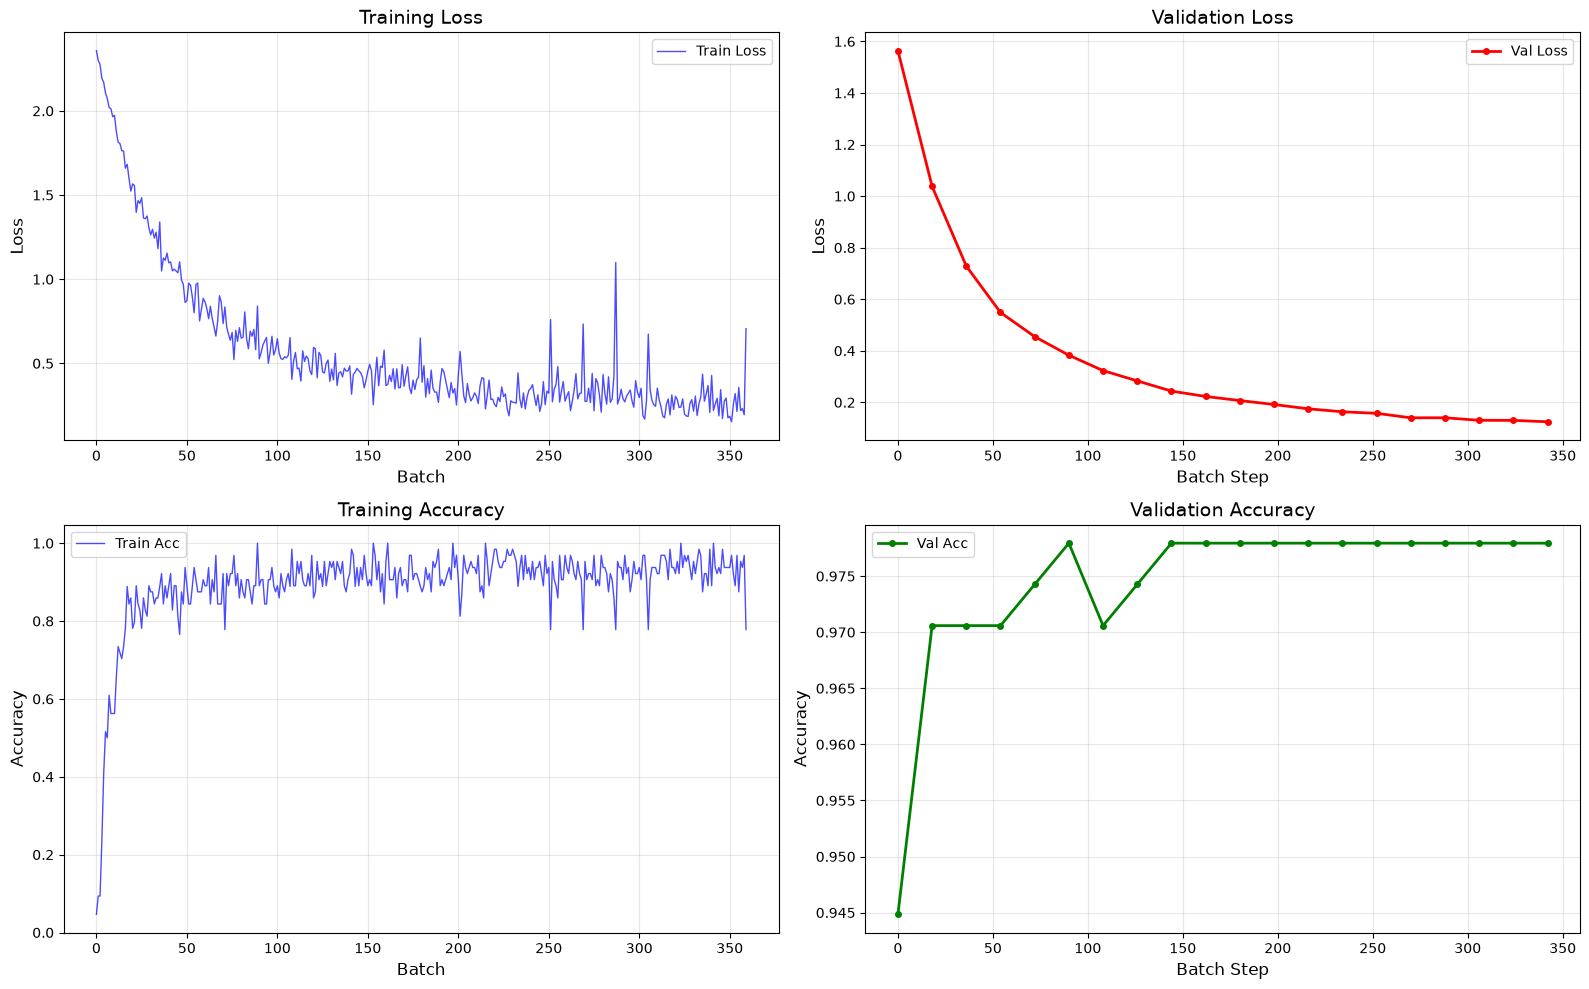


最终训练损失: 0.7062
最终训练准确率: 0.7778
最终验证损失: 0.1246
最终验证准确率: 0.9779

最佳验证损失: 0.1246 (Step 342)
最佳验证准确率: 0.9779 (Step 90)


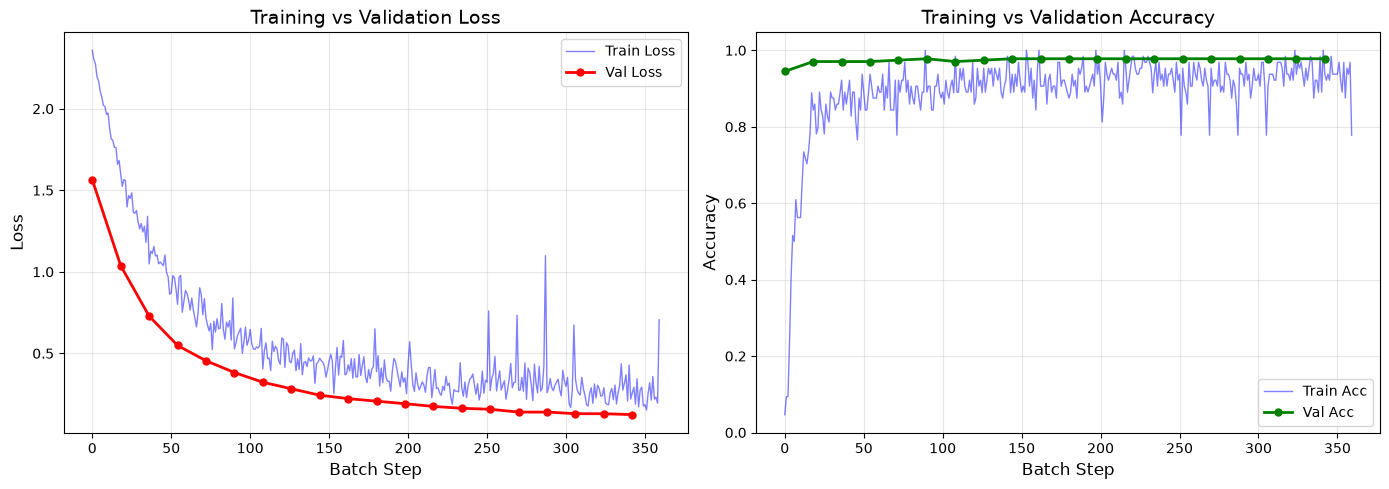

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 获取训练和验证的历史记录
train_loss_history = Resnet50Trainer.history.train_loss_history
train_acc_history = Resnet50Trainer.history.train_acc_history
val_loss_history = Resnet50Trainer.history.val_loss_history
val_acc_history = Resnet50Trainer.history.val_acc_history

print(f"训练集记录点数: {len(train_loss_history)}")
print(f"验证集记录点数: {len(val_loss_history)}")

if len(train_loss_history) > 0 and len(val_loss_history) > 0:
    # 创建2x2子图
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 训练损失曲线
    axes[0, 0].plot(train_loss_history, 'b-', linewidth=1, alpha=0.7, label='Train Loss')
    axes[0, 0].set_xlabel('Batch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Training Loss', fontsize=14)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 验证损失曲线
    val_steps = np.arange(0, len(val_loss_history)) * trainer.eval_step
    axes[0, 1].plot(val_steps, val_loss_history, 'r-', linewidth=2, marker='o', markersize=4, label='Val Loss')
    axes[0, 1].set_xlabel('Batch Step', fontsize=12)
    axes[0, 1].set_ylabel('Loss', fontsize=12)
    axes[0, 1].set_title('Validation Loss', fontsize=14)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 训练准确率曲线
    axes[1, 0].plot(train_acc_history, 'b-', linewidth=1, alpha=0.7, label='Train Acc')
    axes[1, 0].set_xlabel('Batch', fontsize=12)
    axes[1, 0].set_ylabel('Accuracy', fontsize=12)
    axes[1, 0].set_title('Training Accuracy', fontsize=14)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 验证准确率曲线
    axes[1, 1].plot(val_steps, val_acc_history, 'g-', linewidth=2, marker='o', markersize=4, label='Val Acc')
    axes[1, 1].set_xlabel('Batch Step', fontsize=12)
    axes[1, 1].set_ylabel('Accuracy', fontsize=12)
    axes[1, 1].set_title('Validation Accuracy', fontsize=14)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 打印最终统计信息
    print(f"\n{'='*60}")
    print(f"最终训练损失: {train_loss_history[-1]:.4f}")
    print(f"最终训练准确率: {train_acc_history[-1]:.4f}")
    print(f"最终验证损失: {val_loss_history[-1]:.4f}")
    print(f"最终验证准确率: {val_acc_history[-1]:.4f}")
    print(f"{'='*60}")
    
    if len(val_loss_history) > 1:
        best_val_loss_idx = np.argmin(val_loss_history)
        best_val_acc_idx = np.argmax(val_acc_history)
        print(f"\n最佳验证损失: {val_loss_history[best_val_loss_idx]:.4f} (Step {val_steps[best_val_loss_idx]})")
        print(f"最佳验证准确率: {val_acc_history[best_val_acc_idx]:.4f} (Step {val_steps[best_val_acc_idx]})")
        
        # 绘制train和val的对比图
        fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
        
        # Loss对比
        axes2[0].plot(train_loss_history, 'b-', linewidth=1, alpha=0.5, label='Train Loss')
        axes2[0].plot(val_steps, val_loss_history, 'r-', linewidth=2, marker='o', markersize=5, label='Val Loss')
        axes2[0].set_xlabel('Batch Step', fontsize=12)
        axes2[0].set_ylabel('Loss', fontsize=12)
        axes2[0].set_title('Training vs Validation Loss', fontsize=14)
        axes2[0].legend()
        axes2[0].grid(True, alpha=0.3)
        
        # Accuracy对比
        axes2[1].plot(train_acc_history, 'b-', linewidth=1, alpha=0.5, label='Train Acc')
        axes2[1].plot(val_steps, val_acc_history, 'g-', linewidth=2, marker='o', markersize=5, label='Val Acc')
        axes2[1].set_xlabel('Batch Step', fontsize=12)
        axes2[1].set_ylabel('Accuracy', fontsize=12)
        axes2[1].set_title('Training vs Validation Accuracy', fontsize=14)
        axes2[1].legend()
        axes2[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('training_curves_combined.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print("没有收集到训练或验证数据！")

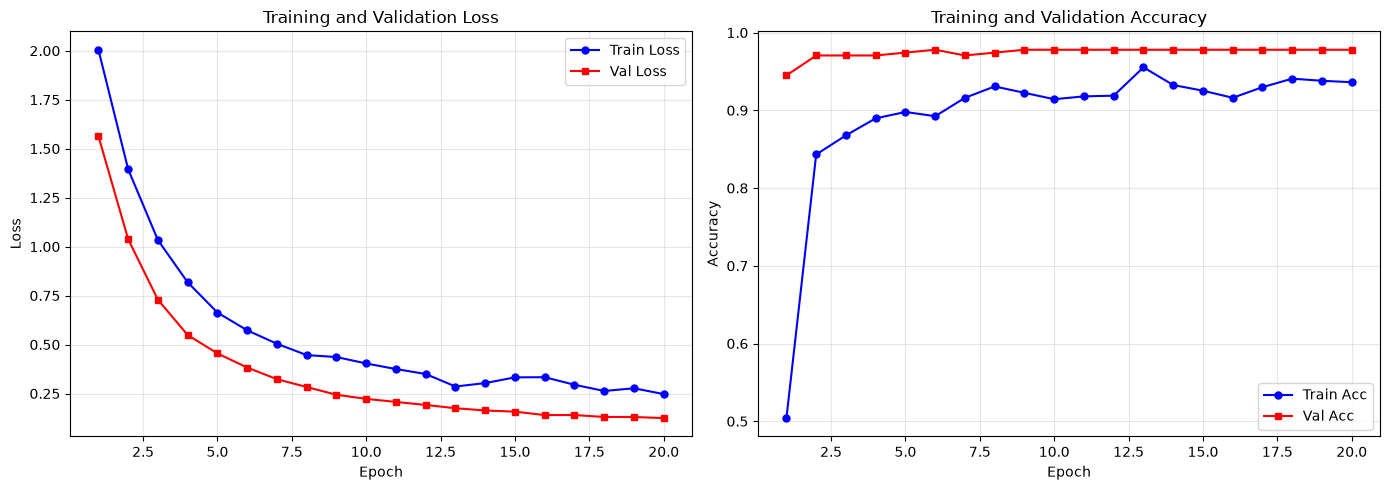

In [15]:
Resnet50Trainer.plot_curves()